In [17]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

# (to Project root)
PROJECT_ROOT = NOTEBOOK_DIR.parent
ROOT = PROJECT_ROOT / "data" / "runs" / "ca"

FIGDIR = PROJECT_ROOT / "data" / "figures" / "phase1"
FIGDIR.mkdir(parents=True, exist_ok=True)

print("Notebook is here :", NOTEBOOK_DIR)
print("Project root     :", PROJECT_ROOT)
print("Data folder      :", ROOT)
print("Exists(data/runs/ca)?", ROOT.exists())


Notebook is here : C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\notebooks
Project root     : C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project
Data folder      : C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\runs\ca
Exists(data/runs/ca)? True


In [21]:
# --- cell 2: common utils for all phases (enhanced with safe overwriting + short labels) ---
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# optional label auto-adjust (for scatter plot annotations)
try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except Exception:
    HAS_ADJUSTTEXT = False


# --------------------------------------------------------------------
# Helper to ensure saved figures always overwrite cleanly
# --------------------------------------------------------------------
def safe_save_plot(fig, figpath, dpi=250):
    """Safely save a matplotlib figure, overwriting any existing file."""
    try:
        if figpath.exists():
            figpath.unlink()  # delete old version if present
        fig.savefig(figpath, dpi=dpi)
        print(f"✅ Saved → {figpath.name}")
    except Exception as e:
        print(f"⚠️ Could not save {figpath.name}: {e}")


# --------------------------------------------------------------------
# Low-level numeric and JSON parsing helpers
# --------------------------------------------------------------------
def _num_to_pct(x):
    """Convert values like 0.82, '82%', or '82.1' to a float in [0,100]."""
    if x is None:
        return None
    if isinstance(x, (int, float, np.integer, np.floating)):
        v = float(x)
    else:
        s = str(x).strip()
        if s.endswith("%"):
            try:
                v = float(s[:-1])
            except:
                return None
        else:
            try:
                v = float(s)
            except:
                return None
    if 0.0 <= v <= 1.0:
        v *= 100.0
    return v


def _try_extract_reach_from_json(js):
    """Look for 'reach_fake' and 'reach_real' (or similar variants) in a JSON object."""
    candF = ["reachF","reach_f","fake_reach","reach_fake","ReachF","Reach_F"]
    candR = ["reachR","reach_r","real_reach","reach_real","ReachR","Reach_R"]
    rF = rR = None
    for k in candF:
        if k in js:
            rF = _num_to_pct(js[k]); break
    for k in candR:
        if k in js:
            rR = _num_to_pct(js[k]); break
    return rF, rR


def _load_summary_csv(batch_dir: Path) -> pd.DataFrame:
    csv_path = batch_dir / "summary.csv"
    if not csv_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    for col in ("reachF","reachR"):
        if col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].astype(str).str.replace("%","", regex=False)
            df[col] = pd.to_numeric(df[col], errors="coerce")
            if df[col].max() is not None and df[col].max() <= 1.0:
                df[col] = df[col] * 100.0
    return df


def _load_per_run_json_rows(batch_dir: Path) -> pd.DataFrame:
    rows = []
    for jp in batch_dir.glob("*.json"):
        try:
            with open(jp, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception:
            continue

        def _row_from(d: dict):
            row = {}
            rF, rR = _try_extract_reach_from_json(d)
            row["reachF"], row["reachR"] = rF, rR
            for k, aliases in {
                "peak_f":   ["peak_f","peakF","peak_fake","fake_peak"],
                "peak_r":   ["peak_r","peakR","peak_real","real_peak"],
                "t_peak_f": ["t_peak_f","tpeak_f","time_to_peak_f","tPeakF"],
                "t_peak_r": ["t_peak_r","tpeak_r","time_to_peak_r","tPeakR"],
            }.items():
                for a in aliases:
                    if a in d:
                        row[k] = d[a]; break
            return row

        if isinstance(data, dict):
            row = _row_from(data)
            if any(v is not None for v in row.values()):
                rows.append(row)
        elif isinstance(data, list):
            for it in data:
                if isinstance(it, dict):
                    row = _row_from(it)
                    if any(v is not None for v in row.values()):
                        rows.append(row)

    if rows:
        df = pd.DataFrame(rows)
        for col in ("reachF","reachR"):
            if col in df.columns:
                df[col] = df[col].map(_num_to_pct)
        return df
    return pd.DataFrame()


def load_batch_dataframe(batch_dir: Path) -> pd.DataFrame:
    """Load both summary.csv and per-run JSON, merge them if both exist."""
    df_csv = _load_summary_csv(batch_dir)
    df_js  = _load_per_run_json_rows(batch_dir)
    if df_csv.empty and df_js.empty:
        return pd.DataFrame()
    if df_csv.empty:
        return df_js.reset_index(drop=True)
    if df_js.empty:
        return df_csv.reset_index(drop=True)

    n = max(len(df_csv), len(df_js))
    def _pad(df):
        if len(df) == n: return df.reset_index(drop=True)
        reps = int(np.ceil(n/len(df)))
        return pd.concat([df]*reps, ignore_index=True).iloc[:n].reset_index(drop=True)

    a = _pad(df_csv)
    b = _pad(df_js)
    merged = a.copy()
    for col in set(b.columns) - set(a.columns):
        merged[col] = np.nan
    for col in b.columns:
        merged[col] = np.where(merged[col].isna(), b[col], merged[col])
    return merged


def summarise_condition(batch_dirs: list[Path]) -> pd.Series:
    """Aggregate multiple batch directories (same condition) into one mean ± std summary."""
    dfs = [load_batch_dataframe(d) for d in batch_dirs if load_batch_dataframe(d) is not None]
    dfs = [d for d in dfs if not d.empty]
    if not dfs:
        return pd.Series(dtype=float)
    df = pd.concat(dfs, ignore_index=True)

    wanted = ["reachF","reachR","peak_f","peak_r","t_peak_f","t_peak_r"]
    cols = [c for c in wanted if c in df.columns]
    if not cols:
        return pd.Series(dtype=float)
    df = df[cols].copy()

    for col in ("reachF","reachR"):
        if col in df.columns:
            df[col] = df[col].map(_num_to_pct)

    out = {}
    for col in cols:
        ser = pd.to_numeric(df[col], errors="coerce")
        out[f"mean_{col}"] = ser.mean()
        out[f"std_{col}"]  = ser.std(ddof=1)
        out[f"n_{col}"]    = ser.notna().sum()
    return pd.Series(out)


def find_dirs_by_prefix(root: Path, prefix: str) -> list[Path]:
    """Return subfolders whose names start with a given prefix."""
    return sorted([p for p in root.iterdir() if p.is_dir() and p.name.startswith(prefix)])


def find_dirs_by_contains(root: Path, contains: str) -> list[Path]:
    """Return subfolders whose names contain a given string."""
    return sorted([p for p in root.iterdir() if p.is_dir() and contains in p.name])


# --------------------------------------------------------------------
# Short label mapping (centralised here so ALL plots inherit it)
# --------------------------------------------------------------------
# Accept both your short run tags and any legacy long names
_LABEL_MAP_PREFIX = {
    "bl": "BL", "baseline": "BL",
    "as": "AS", "async": "AS",
    "ref": "REF", "refractory": "REF",
    "mis": "MIS", "misclass": "MIS",
    "as_ref": "AS+REF",
    "as_mis": "AS+MIS",
    "ref_mis": "REF+MIS",
    "as_ref_mis": "AS+REF+MIS",
    "het": "HET",
    "spa": "SPA",
    "het_spa": "HET+SPA",
    "full": "FULL",
}

# To make matching robust, test longer keys first (e.g. 'as_ref_mis' before 'as')
_PREFIX_ORDER = sorted(_LABEL_MAP_PREFIX.keys(), key=len, reverse=True)

def infer_prefix_and_label(folder_name: str) -> tuple[str, str]:
    """Return ('cond_prefix', 'SHORT_LABEL') from a batch folder name."""
    name = folder_name.lower()
    # Prefer exact/startswith of known prefixes
    for key in _PREFIX_ORDER:
        if name == key or name.startswith(key + "_"):
            return key, _LABEL_MAP_PREFIX[key]
    # Fallback: take text before first underscore and try mapping
    base = name.split("_")[0]
    label = _LABEL_MAP_PREFIX.get(base, base.upper())
    return base, label

def label_for(name: str) -> str:
    """
    Return the short, pretty label (BL, AS, REF, MIS, AS+MIS, ... , FULL)
    for a given condition key or folder name.
    Works with bare keys ('bl', 'as_ref_mis') and folder names ('as_ref_mis_20251014-123456').
    """
    _, lab = infer_prefix_and_label(str(name))
    return lab

def shorten_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Add a 'short_label' column derived from df['cond'] (or from folder names)."""
    if "cond" not in df.columns:
        return df
    df = df.copy()
    def _lab(cond):
        prefix, lab = infer_prefix_and_label(str(cond))
        return lab
    df["short_label"] = df["cond"].map(_lab)
    return df


# --------------------------------------------------------------------
# Plotting utilities (all overwrite-safe using safe_save_plot)
# --------------------------------------------------------------------
def plot_grouped_reach(df, label_col, figpath, title):
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    w = 0.38
    yF, eF = df["mean_reachF"].to_numpy(), df["std_reachF"].to_numpy()
    yR, eR = df["mean_reachR"].to_numpy(), df["std_reachR"].to_numpy()

    fig, ax = plt.subplots(figsize=(11,6))
    ax.bar(x - w/2, yF, width=w, yerr=eF, capsize=3, label="Fake Reach (%)")
    ax.bar(x + w/2, yR, width=w, yerr=eR, capsize=3, label="Real Reach (%)")
    ax.set_ylabel("Reach (%)")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left")
    plt.tight_layout()
    safe_save_plot(fig, figpath, dpi=200)
    plt.show()


def plot_time_to_peak(df, label_col, figpath, title):
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    tpf, tpr = df["mean_t_peak_f"].to_numpy(), df["mean_t_peak_r"].to_numpy()
    ef, er   = df["std_t_peak_f"].to_numpy(), df["std_t_peak_r"].to_numpy()

    fig, ax = plt.subplots(figsize=(11,6))
    ax.errorbar(x, tpf, yerr=ef, marker="o", linewidth=2, label="Fake t_peak")
    ax.errorbar(x, tpr, yerr=er, marker="s", linewidth=2, label="Real t_peak")
    ax.set_title(title)
    ax.set_ylabel("Time steps (ticks)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    safe_save_plot(fig, figpath, dpi=200)
    plt.show()


def plot_peak_bars(df, label_col, figpath, title):
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    w = 0.38
    pf, pr = df["mean_peak_f"].to_numpy(), df["mean_peak_r"].to_numpy()
    sf, sr = df["std_peak_f"].to_numpy(), df["std_peak_r"].to_numpy()

    fig, ax = plt.subplots(figsize=(11,6))
    ax.bar(x - w/2, pf, width=w, yerr=sf, capsize=3, label="Peak Fake (posters)")
    ax.bar(x + w/2, pr, width=w, yerr=sr, capsize=3, label="Peak Real (posters)")
    ax.set_title(title)
    ax.set_ylabel("Number of posters at peak")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    safe_save_plot(fig, figpath, dpi=200)
    plt.show()


def plot_scatter_peak_vs_reach_fake(df, label_col, figpath, title):
    """Scatter for Phase 1 (keep original style)."""
    labels = df[label_col].tolist()
    pf, rf = df["mean_peak_f"].to_numpy(), df["mean_reachF"].to_numpy()
    sf_pf, sf_rf = df["std_peak_f"].to_numpy(), df["std_reachF"].to_numpy()

    fig, ax = plt.subplots(figsize=(9,7))
    ax.errorbar(pf, rf, xerr=sf_pf, yerr=sf_rf,
                fmt="o", ms=8, capsize=3, ecolor="gray", alpha=0.8)
    texts = []
    for x, y, name in zip(pf, rf, labels):
        texts.append(ax.text(x, y, name, fontsize=9))
    if HAS_ADJUSTTEXT:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.4, color="gray"))
    ax.set_xlabel("Peak Fake (posters)")
    ax.set_ylabel("Fake Reach (%)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    safe_save_plot(fig, figpath, dpi=250)
    plt.show()


def plot_peak_vs_reach_bar(df, label_col, figpath, title, scale=20):
    """Grouped-bar version for Phase 2 & 3."""
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    w = 0.35
    y_reach, e_reach = df["mean_reachF"].to_numpy(), df["std_reachF"].to_numpy()
    y_peak,  e_peak  = df["mean_peak_f"].to_numpy(),  df["std_peak_f"].to_numpy()
    y_peak_s, e_peak_s = y_peak/scale, e_peak/scale

    fig, ax = plt.subplots(figsize=(11,6))
    ax.bar(x - w/2, y_reach, width=w, yerr=e_reach, capsize=3,
           label="Fake Reach (%)", alpha=0.85)
    ax.bar(x + w/2, y_peak_s, width=w, yerr=e_peak_s, capsize=3,
           label=f"Peak Fake (÷{scale})", alpha=0.75)
    ax.set_ylabel("Fake Reach (%) / Peak Fake (scaled)")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0, max(105, np.nanmax(y_reach)+10))
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    safe_save_plot(fig, figpath, dpi=250)
    plt.show()


# --------------------------------------------------------------------
# Phase loaders that also attach short labels
# (expects ROOT from Cell 1 to point at data/runs/ca)
# --------------------------------------------------------------------
def _summarise_for_prefixes(root: Path, prefixes: list[str]) -> pd.DataFrame:
    """Build a tidy df with 'cond' (folder prefix) and 'short_label' for given condition prefixes."""
    rows = []
    for pre in prefixes:
        dirs = find_dirs_by_prefix(root, pre)
        if not dirs:
            continue
        s = summarise_condition(dirs)
        if s.empty:
            continue
        # keep the original condition key for traceability
        row = {"cond": pre}
        row.update(s.to_dict())
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df = shorten_labels(df)
    return df

# ---- Define which runs belong to each phase (by your actual folder prefixes) ----
PHASE0_PREFIXES = ["bl", "baseline"]
PHASE1_PREFIXES = ["as", "ref", "mis", "as_mis", "ref_mis", "as_ref", "as_ref_mis"]
PHASE2_PREFIXES = ["het", "spa", "het_spa"]
PHASE3_PREFIXES = ["as", "mis", "ref", "as_mis", "ref_mis", "as_ref", "as_ref_mis", "het", "spa", "het_spa", "full"]

def load_phase0(root: Path) -> pd.DataFrame:
    return _summarise_for_prefixes(root, PHASE0_PREFIXES)

def load_phase1(root: Path) -> pd.DataFrame:
    return _summarise_for_prefixes(root, PHASE1_PREFIXES)

def load_phase2(root: Path) -> pd.DataFrame:
    return _summarise_for_prefixes(root, PHASE2_PREFIXES)

def load_phase3(root: Path) -> pd.DataFrame:
    return _summarise_for_prefixes(root, PHASE3_PREFIXES)

# --- Build global dataframes here so Cells 3–6 can just use them ---
try:
    # ROOT is defined in Cell 1 and points to data/runs/ca
    DF_PHASE0 = load_phase0(ROOT)
    DF_PHASE1 = load_phase1(ROOT)
    DF_PHASE2 = load_phase2(ROOT)
    DF_PHASE3 = load_phase3(ROOT)
    print("✅ Phase data loaded:",
          f"P0={len(DF_PHASE0)} rows, P1={len(DF_PHASE1)} rows, "
          f"P2={len(DF_PHASE2)} rows, P3={len(DF_PHASE3)} rows")
except NameError:
    print("⚠️ ROOT is not defined. Make sure Cell 1 (paths) ran successfully.")


✅ Phase data loaded: P0=2 rows, P1=7 rows, P2=3 rows, P3=11 rows


✅ Phase 0 — Baseline summary (mean ± std, with sample counts):


,mean_reachF,std_reachF,n_reachF,mean_reachR,std_reachR,n_reachR,mean_peak_f,std_peak_f,n_peak_f,mean_peak_r,std_peak_r,n_peak_r,mean_t_peak_f,std_t_peak_f,n_t_peak_f,mean_t_peak_r,std_t_peak_r,n_t_peak_r,cond,Condition
0,62.653,7.006,219.0,99.997,0.015,219.0,542.828,140.999,203.0,2154.305,31.588,203.0,22.892,4.008,203.0,56.424,2.97,203.0,bl,BL


Saved summary Excel → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase0\phase0_baseline_metrics.xlsx
✅ Saved → phase0_plot1_reach_grouped.png


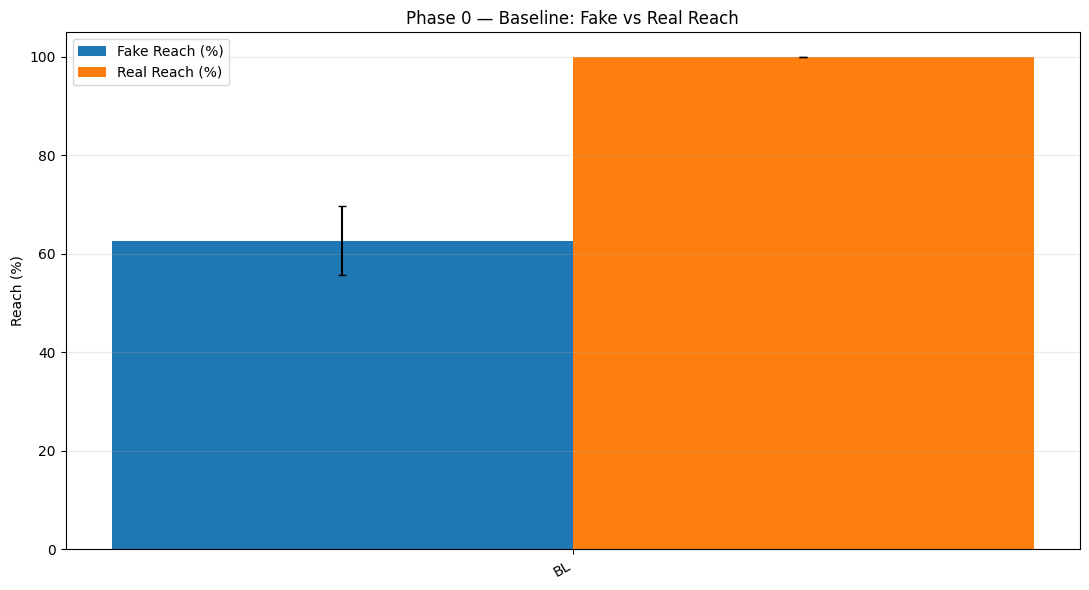

✅ Saved → phase0_plot2_time_to_peak.png


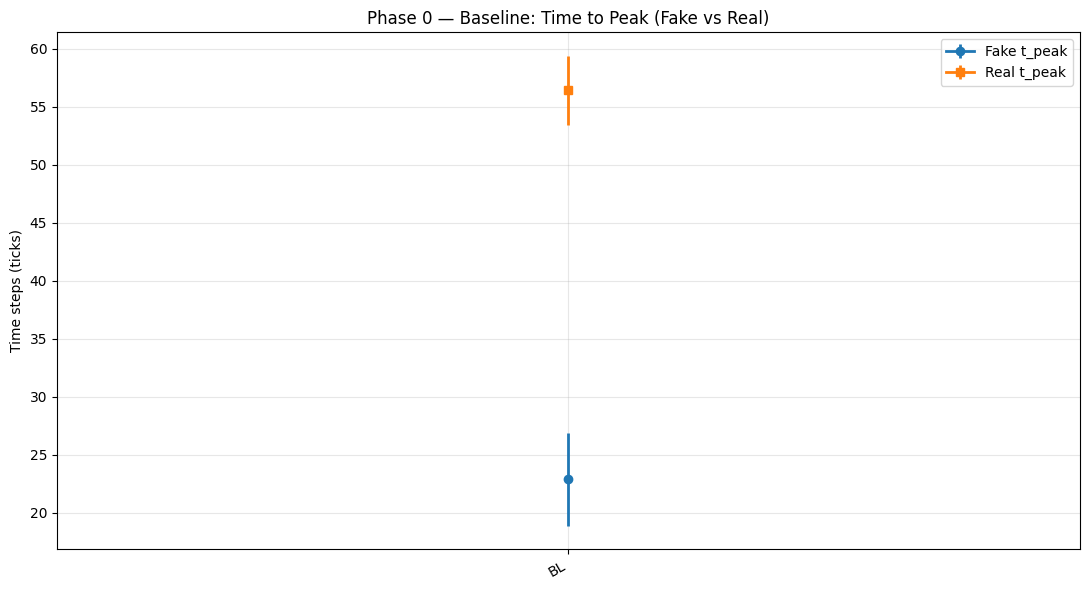

✅ Saved → phase0_plot3_peak_posters.png


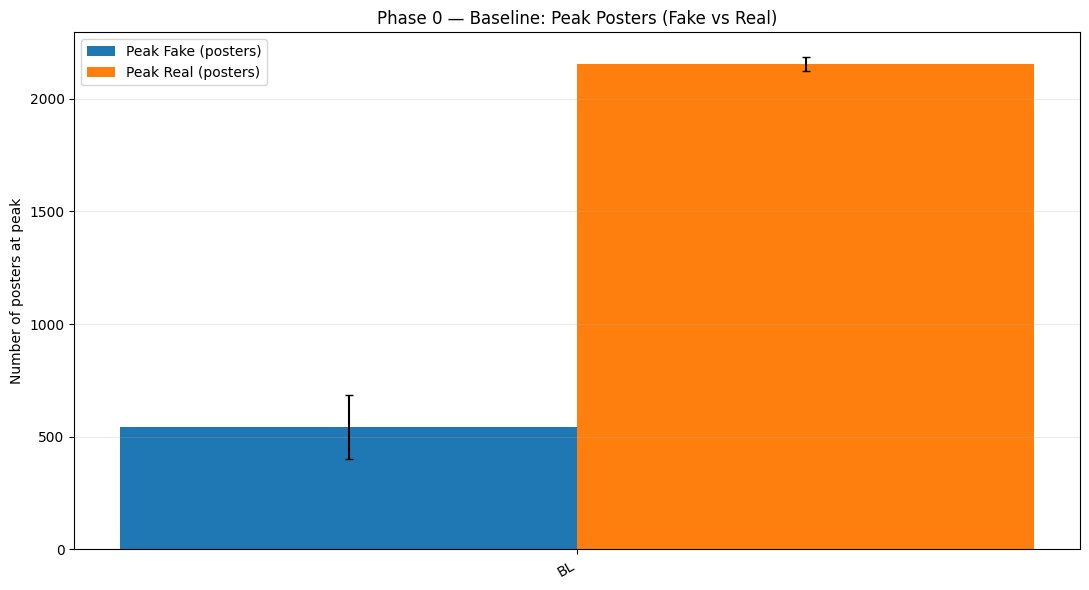

In [22]:
# --- cell 3: Phase 0 — Baseline Analysis (randomness + decay only) ---
from pathlib import Path
import pandas as pd
import numpy as np

# create a subfolder for Phase 0 charts
FIGDIR0 = PROJECT_ROOT / "data" / "figures" / "phase0"
FIGDIR0.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Step 1: find any "baseline" style runs
# ---------------------------------------------------------
# accept both "bl_", "baseline_", and legacy "sync_" folder names
baseline_dirs = []
baseline_dirs += find_dirs_by_prefix(ROOT, "bl_")
baseline_dirs += find_dirs_by_prefix(ROOT, "baseline_")
baseline_dirs += find_dirs_by_prefix(ROOT, "sync_")

if not baseline_dirs:
    print("⚠️  No baseline folders found under:", ROOT)
    print("Expected folder names like 'bl_20251014-184529' or 'baseline_20251014-XXXXXX'.")
else:
    # -----------------------------------------------------
    # Step 2: calculate averages/std for all baseline runs
    # -----------------------------------------------------
    baseline_stats = summarise_condition(baseline_dirs)

    if baseline_stats.empty:
        print("No valid summary data found in baseline folders.")
    else:
        # assemble into single-row dataframe
        phase0_df = pd.DataFrame([baseline_stats])

        # keep a machine-friendly key and a short human label for plotting
        # NOTE: requires 'label_for' from Cell 2
        phase0_df["cond"] = "bl"
        phase0_df["Condition"] = label_for("bl")  # -> "BL"

        # show quick summary table
        print("✅ Phase 0 — Baseline summary (mean ± std, with sample counts):")
        display(phase0_df.round(3))

        # -------------------------------------------------
        # Step 3: save metrics table to Excel for reference
        # -------------------------------------------------
        excel_out = FIGDIR0 / "phase0_baseline_metrics.xlsx"
        with pd.ExcelWriter(excel_out, engine="xlsxwriter") as xw:
            phase0_df.set_index("Condition").round(3).to_excel(xw, sheet_name="Phase0_Baseline")
        print(f"Saved summary Excel → {excel_out}")

        # -------------------------------------------------
        # Step 4: generate baseline plots (only if columns exist)
        # -------------------------------------------------

        # (1) Fake vs Real reach
        need_reach = {"mean_reachF", "std_reachF", "mean_reachR", "std_reachR"}
        if need_reach.issubset(phase0_df.columns):
            plot_grouped_reach(
                phase0_df,
                label_col="Condition",
                figpath=FIGDIR0 / "phase0_plot1_reach_grouped.png",
                title="Phase 0 — Baseline: Fake vs Real Reach"
            )
        else:
            print("Skipped Reach plot — required columns missing.")

        # (2) Time-to-peak chart
        need_tpeak = {"mean_t_peak_f", "std_t_peak_f", "mean_t_peak_r", "std_t_peak_r"}
        if need_tpeak.issubset(phase0_df.columns):
            plot_time_to_peak(
                phase0_df,
                label_col="Condition",
                figpath=FIGDIR0 / "phase0_plot2_time_to_peak.png",
                title="Phase 0 — Baseline: Time to Peak (Fake vs Real)"
            )
        else:
            print("Skipped Time-to-Peak plot — columns missing.")

        # (3) Peak number of posters
        need_peaks = {"mean_peak_f", "std_peak_f", "mean_peak_r", "std_peak_r"}
        if need_peaks.issubset(phase0_df.columns):
            plot_peak_bars(
                phase0_df,
                label_col="Condition",
                figpath=FIGDIR0 / "phase0_plot3_peak_posters.png",
                title="Phase 0 — Baseline: Peak Posters (Fake vs Real)"
            )
        else:
            print("Skipped Peak-posters plot — columns missing.")


✅ Phase 1 — Micro mechanisms summary (mean ± std; counts in n_* columns):


,mean_reachF,std_reachF,n_reachF,mean_reachR,std_reachR,n_reachR,mean_peak_f,std_peak_f,n_peak_f,mean_peak_r,std_peak_r,n_peak_r,mean_t_peak_f,std_t_peak_f,n_t_peak_f,mean_t_peak_r,std_t_peak_r,n_t_peak_r,cond,Condition
0,62.653,7.006,219.0,99.997,0.015,219.0,542.828,140.999,203.0,2154.305,31.588,203.0,22.892,4.008,203.0,56.424,2.970,203.0,bl,BL
1,76.143,11.781,329.0,99.508,1.608,329.0,568.833,281.158,323.0,2196.186,97.746,323.0,23.207,5.465,323.0,57.297,2.885,323.0,as,AS
2,74.562,10.462,172.0,96.033,4.702,172.0,795.127,223.120,166.0,2056.259,195.868,166.0,32.343,4.331,166.0,58.946,0.227,166.0,ref,REF
3,80.451,3.805,100.0,99.978,0.114,100.0,179.860,43.846,100.0,2143.970,22.273,100.0,16.120,3.053,100.0,56.510,2.267,100.0,mis,MIS
4,77.297,11.298,40.0,99.086,1.723,40.0,804.100,235.669,40.0,2196.800,134.838,40.0,27.400,3.699,40.0,58.850,0.533,40.0,as_ref,AS+REF
5,81.576,2.933,20.0,100.000,0.000,20.0,182.350,39.016,20.0,2165.750,14.078,20.0,15.050,1.849,20.0,55.700,2.904,20.0,as_mis,AS+MIS
6,86.956,1.589,20.0,99.942,0.124,20.0,588.600,96.273,20.0,2248.400,40.141,20.0,28.650,2.739,20.0,58.950,0.224,20.0,ref_mis,REF+MIS
7,87.044,3.597,20.0,100.000,0.000,20.0,629.700,152.314,20.0,2305.000,27.792,20.0,25.000,3.277,20.0,58.700,0.733,20.0,as_ref_mis,AS+REF+MIS


Saved Excel → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase1\phase1_metrics.xlsx
✅ Saved → phase1_plot1_reach_grouped.png


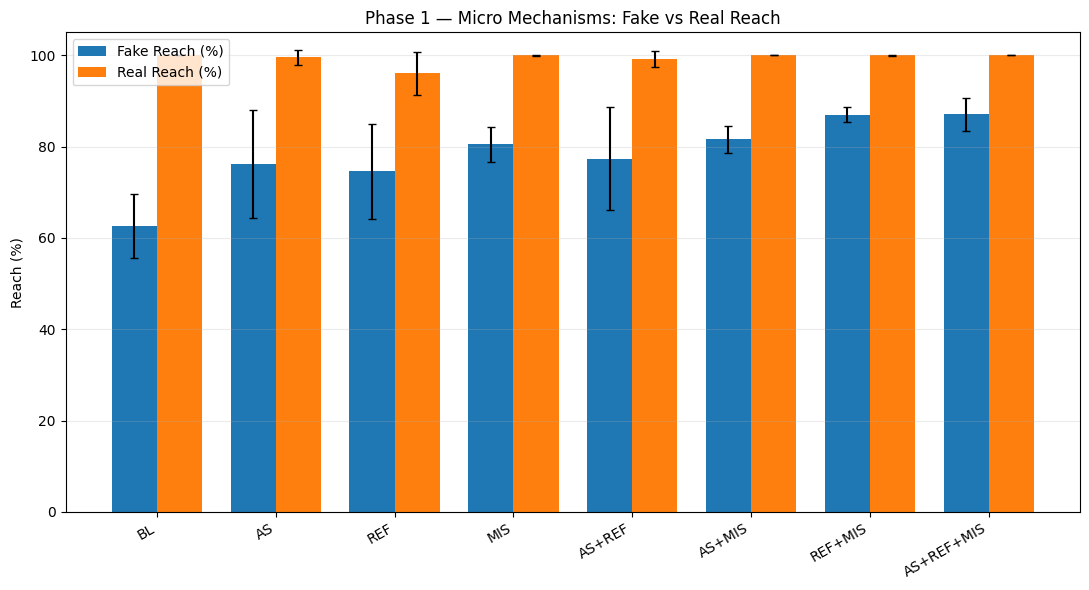

✅ Saved → phase1_plot2_time_to_peak.png


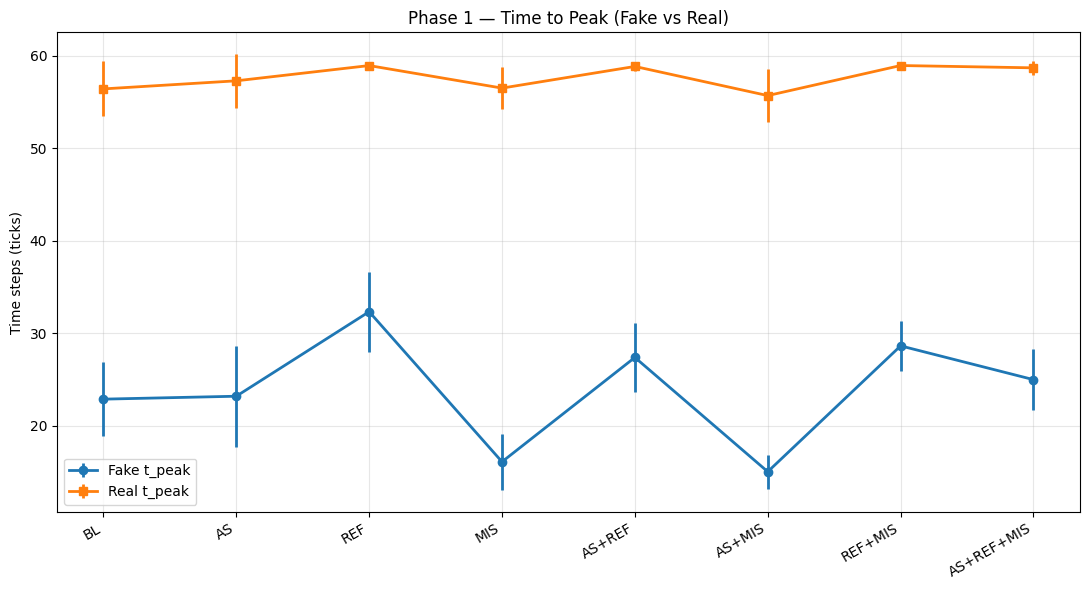

✅ Saved → phase1_plot3_peak_posters.png


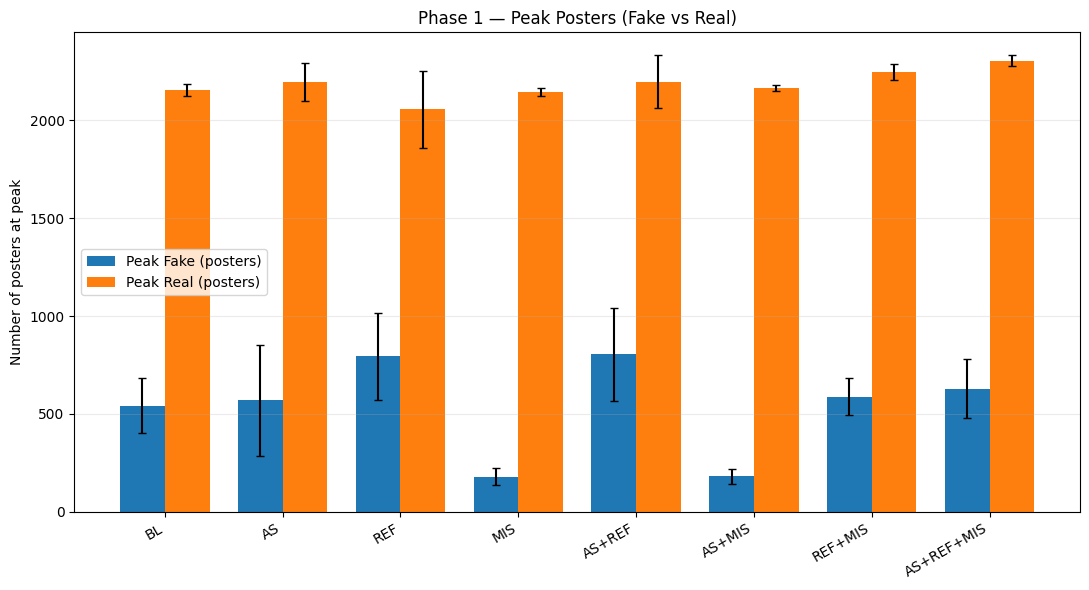

✅ Saved → phase1_plot4_scatter_peak_vs_reach_fake.png


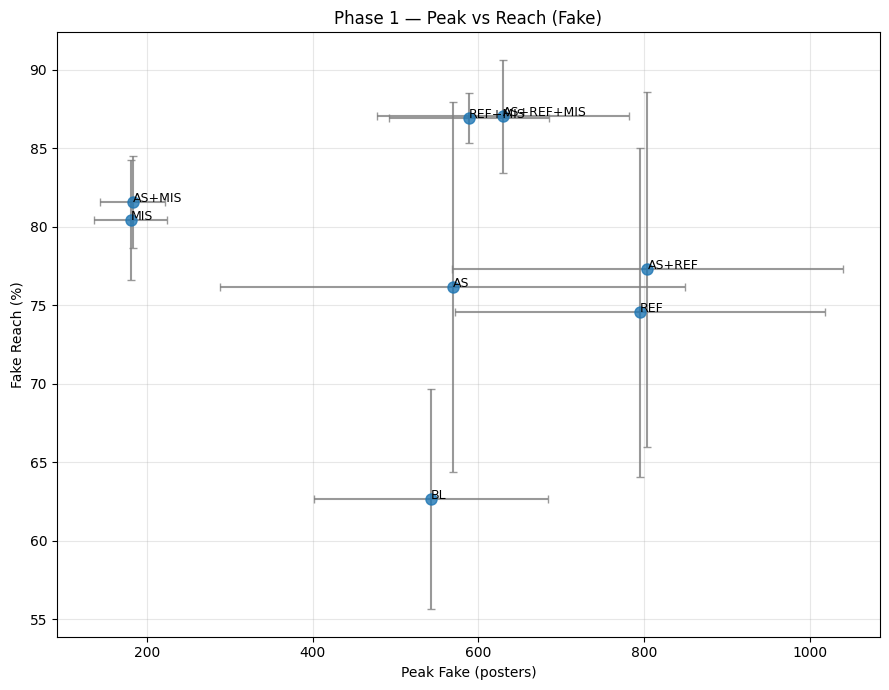

In [23]:
# --- cell 4: Phase 1 — Micro mechanisms (Async / Refractory / Misclass) ---
from pathlib import Path
import pandas as pd
import numpy as np

# output folder for Phase 1 figures
FIGDIR1 = PROJECT_ROOT / "data" / "figures" / "phase1"
FIGDIR1.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------------
# Step 1: define Phase-1 condition keys and how to find their folders
# --------------------------------------------------------------------
# We drive everything by the *prefix keys* that match your run folders.
# Each item is a short "cond_key" like 'as', 'ref_mis', etc.
P1_KEYS = [
    "bl",          # Baseline (for convenient side-by-side)
    "as",          # Async (M1)
    "ref",         # Refractory (M2)
    "mis",         # Misclassification (M3)
    "as_ref",      # M1+M2
    "as_mis",      # M1+M3
    "ref_mis",     # M2+M3
    "as_ref_mis",  # M1+M2+M3
]

# Map each cond_key to one or more acceptable on-disk folder prefixes
# (supports your current short prefixes and legacy long ones)
LEGACY_PREFIXES = {
    "bl":          ["bl_", "baseline_", "sync_"],
    "as":          ["as_", "async_"],
    "ref":         ["ref_", "refractory_"],
    "mis":         ["mis_", "misclass_"],
    "as_ref":      ["as_ref_"],
    "as_mis":      ["as_mis_"],
    "ref_mis":     ["ref_mis_"],
    "as_ref_mis":  ["as_ref_mis_"],
}

rows = []
missing = []

for cond_key in P1_KEYS:
    prefixes = LEGACY_PREFIXES.get(cond_key, [f"{cond_key}_"])
    found_dirs = []
    for pref in prefixes:
        found_dirs.extend(find_dirs_by_prefix(ROOT, pref))

    if not found_dirs:
        missing.append(cond_key)
        continue

    stats = summarise_condition(found_dirs)
    if stats.empty:
        missing.append(cond_key)
        continue

    # Attach machine key and human-friendly short label (from Cell 2 -> label_for)
    row = stats.to_dict()
    row["cond"] = cond_key
    row["Condition"] = label_for(cond_key)   # e.g., "AS", "REF+MIS"
    rows.append(row)

# --------------------------------------------------------------------
# Step 2: assemble the Phase-1 summary dataframe (ordered nicely)
# --------------------------------------------------------------------
phase1_df = pd.DataFrame(rows)
if phase1_df.empty:
    raise RuntimeError(
        "No Phase 1 batches found. "
        "Check that folders like 'as_YYYYMMDD-HHMMSS' exist under data/runs/ca."
    )

# keep the same display order as P1_KEYS
order_map = {label_for(k): i for i, k in enumerate(P1_KEYS)}
phase1_df["__order"] = phase1_df["Condition"].map(order_map).fillna(999)
phase1_df = (
    phase1_df
    .sort_values("__order")
    .drop(columns="__order")
    .reset_index(drop=True)
)

# show what we missed (if anything)
if missing:
    # present them as short labels for clarity
    miss_labels = ", ".join(label_for(m) for m in missing)
    print("⚠️  These Phase-1 conditions were not found (skipped):", miss_labels)

# Quick preview
print("✅ Phase 1 — Micro mechanisms summary (mean ± std; counts in n_* columns):")
display(phase1_df.round(3))

# --------------------------------------------------------------------
# Step 3: save a tidy Excel table for the report appendix
# --------------------------------------------------------------------
excel_out = FIGDIR1 / "phase1_metrics.xlsx"
with pd.ExcelWriter(excel_out, engine="xlsxwriter") as xw:
    phase1_df.set_index("Condition").round(3).to_excel(xw, sheet_name="Phase1_Summary")
print(f"Saved Excel → {excel_out}")

# --------------------------------------------------------------------
# Step 4: Figures for Phase-1
# (plots only render if the required columns exist)
# --------------------------------------------------------------------

# (1) Fake vs Real reach (grouped bars)
need_reach = {"mean_reachF","std_reachF","mean_reachR","std_reachR"}
if need_reach.issubset(phase1_df.columns):
    plot_grouped_reach(
        phase1_df,
        label_col="Condition",   # <- short labels like BL, AS, REF, ...
        figpath=FIGDIR1 / "phase1_plot1_reach_grouped.png",
        title="Phase 1 — Micro Mechanisms: Fake vs Real Reach"
    )
else:
    print("Skipped Plot 1 (Reach): missing reach columns.")

# (2) Time to peak (error-line)
need_tpeak = {"mean_t_peak_f","std_t_peak_f","mean_t_peak_r","std_t_peak_r"}
if need_tpeak.issubset(phase1_df.columns):
    plot_time_to_peak(
        phase1_df,
        label_col="Condition",
        figpath=FIGDIR1 / "phase1_plot2_time_to_peak.png",
        title="Phase 1 — Time to Peak (Fake vs Real)"
    )
else:
    print("Skipped Plot 2 (Time-to-peak): missing columns.")

# (3) Peak posters (grouped bars)
need_peaks = {"mean_peak_f","std_peak_f","mean_peak_r","std_peak_r"}
if need_peaks.issubset(phase1_df.columns):
    plot_peak_bars(
        phase1_df,
        label_col="Condition",
        figpath=FIGDIR1 / "phase1_plot3_peak_posters.png",
        title="Phase 1 — Peak Posters (Fake vs Real)"
    )
else:
    print("Skipped Plot 3 (Peaks): missing columns.")

# (4) Diagnostic: Peak-vs-Reach (Fake) scatter with error bars
need_scatter = {"mean_peak_f","std_peak_f","mean_reachF","std_reachF"}
if need_scatter.issubset(phase1_df.columns):
    plot_scatter_peak_vs_reach_fake(
        phase1_df,
        label_col="Condition",
        figpath=FIGDIR1 / "phase1_plot4_scatter_peak_vs_reach_fake.png",
        title="Phase 1 — Peak vs Reach (Fake)"
    )
else:
    print("Skipped Plot 4 (Peak vs Reach): need peak_f and reachF columns.")


✅ Phase 2 — Macro mechanisms summary (mean ± std; counts in n_* columns):


,mean_reachF,std_reachF,n_reachF,mean_reachR,std_reachR,n_reachR,mean_peak_f,std_peak_f,n_peak_f,mean_peak_r,std_peak_r,n_peak_r,mean_t_peak_f,std_t_peak_f,n_t_peak_f,mean_t_peak_r,std_t_peak_r,n_t_peak_r,cond,Condition
0,62.662,6.738,40.0,99.660,0.923,40.0,452.8,132.157,40.0,2043.3,90.121,40.0,26.775,3.301,40.0,58.075,1.685,40.0,het,HET
1,60.754,5.868,20.0,99.148,1.547,20.0,427.4,102.482,20.0,1971.0,74.795,20.0,29.150,4.246,20.0,58.600,0.883,20.0,spa,SPA
2,61.284,5.382,20.0,99.322,1.228,20.0,439.1,112.852,20.0,1964.7,52.158,20.0,28.250,2.789,20.0,58.750,0.444,20.0,het_spa,HET+SPA


Saved Excel → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase2\phase2_metrics.xlsx
✅ Saved → phase2_plot1_reach_grouped.png


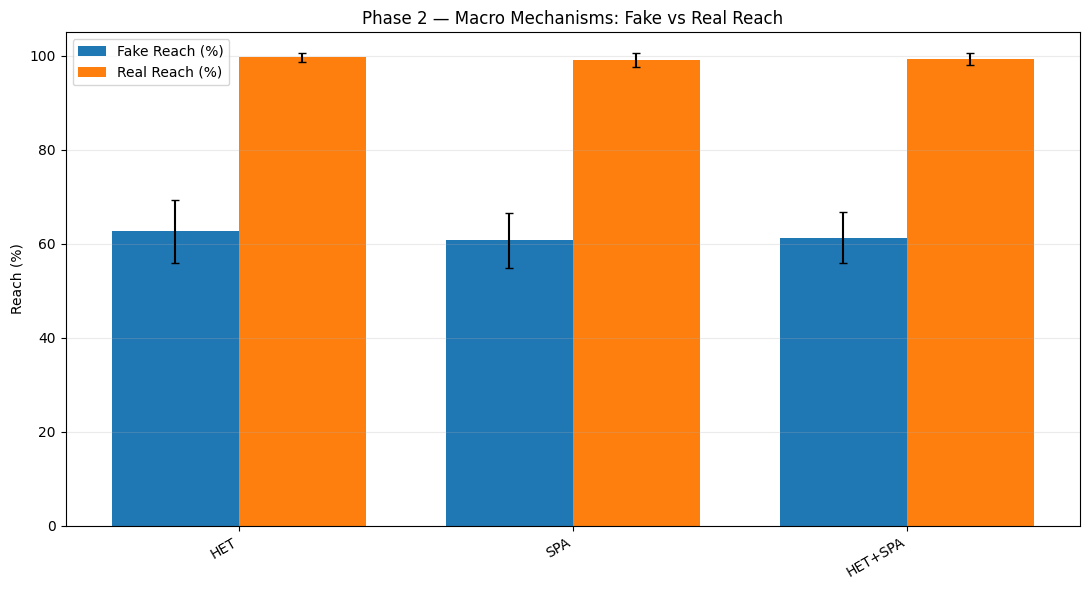

✅ Saved → phase2_plot2_time_to_peak.png


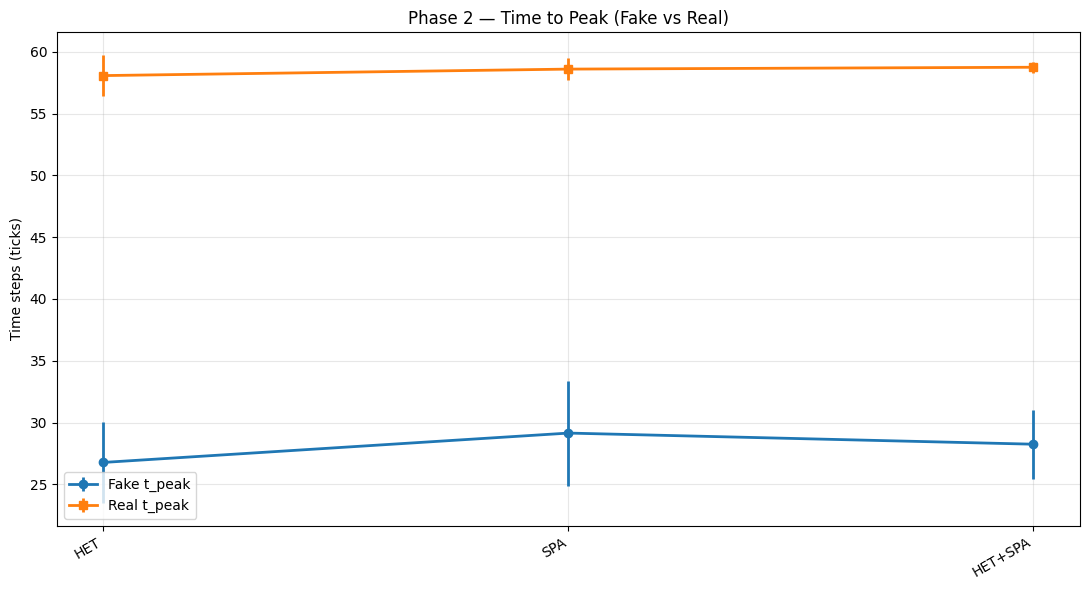

✅ Saved → phase2_plot3_peak_posters.png


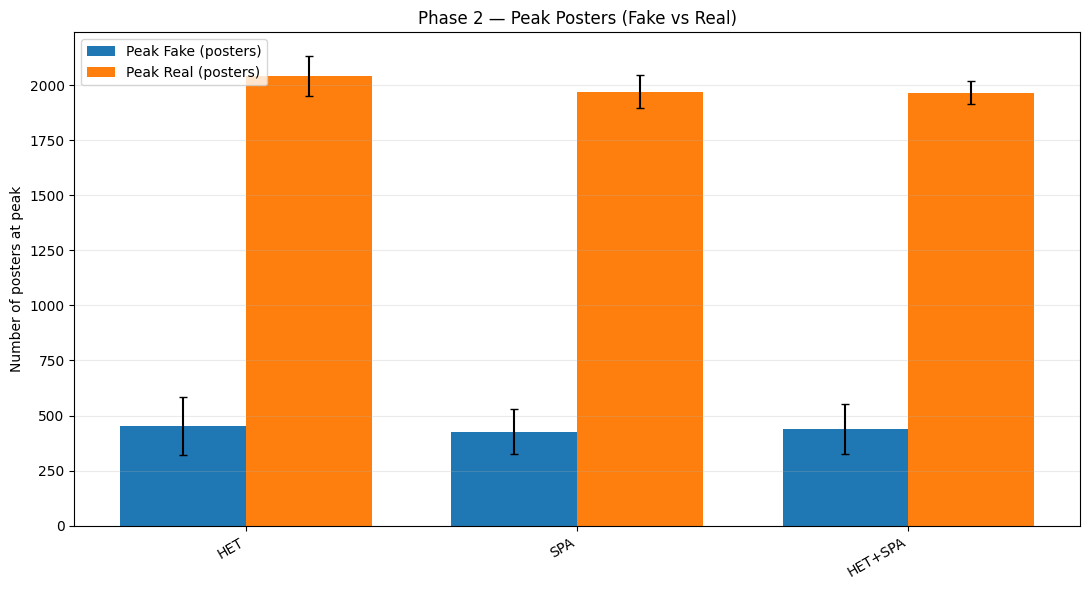

✅ Saved → phase2_plot4_peak_vs_reach_fake_grouped.png


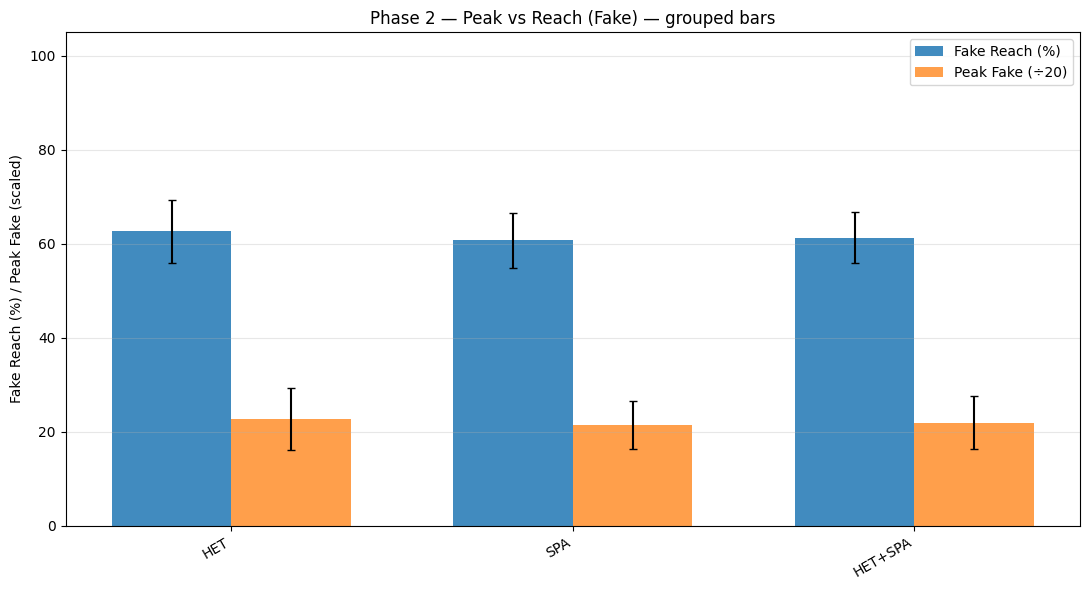

In [26]:
# --- cell 5: Phase 2 — Macro mechanisms (Heterogeneity / Spatial) ---
from pathlib import Path
import pandas as pd
import numpy as np
import re

# output folder for Phase 2 figures
FIGDIR2 = PROJECT_ROOT / "data" / "figures" / "phase2"
FIGDIR2.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------------
# Step 1: define Phase-2 condition keys and how to find their folders
# --------------------------------------------------------------------
# Drive by short keys that match your run naming; label_for() (Cell 2) gives short plot labels.
P2_KEYS = [
    "het",       # M4: Heterogeneity
    "spa",       # M5: Spatial
    "het_spa",   # M4+M5
]

# Accept both short and legacy prefixes on disk
LEGACY_PREFIXES_P2 = {
    "het":     ["het_"],            # also tolerate token find if needed
    "spa":     ["spa_"],
    "het_spa": ["het_spa_"],
}

rows2 = []
missing2 = []

for cond_key in P2_KEYS:
    prefixes = LEGACY_PREFIXES_P2.get(cond_key, [f"{cond_key}_"])
    found_dirs = []
    for pref in prefixes:
        # exact prefix match (your current folder style)
        found_dirs.extend(find_dirs_by_prefix(ROOT, pref))

        # tolerant fallback: token contains (legacy/edge cases)
        token = pref.rstrip("_")
        if not found_dirs:
            found_dirs.extend(find_dirs_by_contains(ROOT, token))

    if not found_dirs:
        missing2.append(cond_key)
        continue

    stats = summarise_condition(found_dirs)
    if stats.empty:
        missing2.append(cond_key)
        continue

    row = stats.to_dict()
    row["cond"] = cond_key
    row["Condition"] = label_for(cond_key)   # -> "HET", "SPA", "HET+SPA"
    rows2.append(row)

# --------------------------------------------------------------------
# Step 2: assemble Phase-2 dataframe and order nicely
# --------------------------------------------------------------------
phase2_df = pd.DataFrame(rows2)
if phase2_df.empty:
    raise RuntimeError(
        "No Phase 2 macro batches found. "
        "Expected folders like 'het_YYYYMMDD-HHMMSS', 'spa_YYYYMMDD-HHMMSS', or 'het_spa_...'."
    )

# keep HET, SPA, HET+SPA order
order_map2 = {label_for(k): i for i, k in enumerate(P2_KEYS)}
phase2_df["__order"] = phase2_df["Condition"].map(order_map2).fillna(999)
phase2_df = (
    phase2_df
    .sort_values("__order")
    .drop(columns="__order")
    .reset_index(drop=True)
)

# display any missing as short labels for clarity
if missing2:
    miss_labels = ", ".join(label_for(m) for m in missing2)
    print("⚠️  These Phase-2 conditions were not found (skipped):", miss_labels)

print("✅ Phase 2 — Macro mechanisms summary (mean ± std; counts in n_* columns):")
display(phase2_df.round(3))

# --------------------------------------------------------------------
# Step 3: save an Excel table for the report appendix
# --------------------------------------------------------------------
excel2 = FIGDIR2 / "phase2_metrics.xlsx"
with pd.ExcelWriter(excel2, engine="xlsxwriter") as xw:
    phase2_df.set_index("Condition").round(3).to_excel(xw, sheet_name="Phase2_Summary")
print(f"Saved Excel → {excel2}")

# --------------------------------------------------------------------
# Step 4: figures for Phase-2 (render only if required columns exist)
# --------------------------------------------------------------------

# (1) Fake vs Real reach (grouped bars)
need_reach = {"mean_reachF","std_reachF","mean_reachR","std_reachR"}
if need_reach.issubset(phase2_df.columns):
    plot_grouped_reach(
        phase2_df,
        label_col="Condition",  # -> HET, SPA, HET+SPA
        figpath=FIGDIR2 / "phase2_plot1_reach_grouped.png",
        title="Phase 2 — Macro Mechanisms: Fake vs Real Reach"
    )
else:
    print("Skipped Plot 1 (Reach): required columns missing.")

# (2) Time to peak (error-line)
need_tpeak = {"mean_t_peak_f","std_t_peak_f","mean_t_peak_r","std_t_peak_r"}
if need_tpeak.issubset(phase2_df.columns):
    plot_time_to_peak(
        phase2_df,
        label_col="Condition",
        figpath=FIGDIR2 / "phase2_plot2_time_to_peak.png",
        title="Phase 2 — Time to Peak (Fake vs Real)"
    )
else:
    print("Skipped Plot 2 (Time-to-peak): missing columns.")

# (3) Peak posters (grouped bars)
need_peaks = {"mean_peak_f","std_peak_f","mean_peak_r","std_peak_r"}
if need_peaks.issubset(phase2_df.columns):
    plot_peak_bars(
        phase2_df,
        label_col="Condition",
        figpath=FIGDIR2 / "phase2_plot3_peak_posters.png",
        title="Phase 2 — Peak Posters (Fake vs Real)"
    )
else:
    print("Skipped Plot 3 (Peaks): missing columns.")

# (4) Peak vs Reach (Fake) — grouped bars (readable even with longer labels)
need_combo = {"mean_peak_f","std_peak_f","mean_reachF","std_reachF"}
if need_combo.issubset(phase2_df.columns):
    plot_peak_vs_reach_bar(
        phase2_df,
        label_col="Condition",
        figpath=FIGDIR2 / "phase2_plot4_peak_vs_reach_fake_grouped.png",
        title="Phase 2 — Peak vs Reach (Fake) — grouped bars",
        scale=20
    )
else:
    print("Skipped Plot 4 (Peak vs Reach): need peak_f and reachF columns.")


✅ Phase 3 — Showcase (BL, micro, macro, combos, FULL):


,mean_reachF,std_reachF,n_reachF,mean_reachR,std_reachR,n_reachR,mean_peak_f,std_peak_f,n_peak_f,mean_peak_r,...,n_peak_r,mean_t_peak_f,std_t_peak_f,n_t_peak_f,mean_t_peak_r,std_t_peak_r,n_t_peak_r,cond,Category,Condition
0,62.653,7.006,219.0,99.997,0.015,219.0,542.828,140.999,203.0,2154.305,...,203.0,22.892,4.008,203.0,56.424,2.970,203.0,bl,baseline,BL
1,63.289,7.695,100.0,100.000,0.000,100.0,482.070,113.309,100.0,2155.540,...,100.0,21.090,2.723,100.0,55.840,3.212,100.0,as,micro,AS
2,80.451,3.805,100.0,99.978,0.114,100.0,179.860,43.846,100.0,2143.970,...,100.0,16.120,3.053,100.0,56.510,2.267,100.0,mis,micro,MIS
3,67.337,6.009,106.0,93.601,4.520,106.0,939.910,151.168,100.0,1928.910,...,100.0,34.760,3.343,100.0,58.990,0.100,100.0,ref,micro,REF
4,81.797,3.292,60.0,100.000,0.000,60.0,182.167,50.363,60.0,2161.000,...,60.0,15.117,2.285,60.0,54.900,3.569,60.0,as_mis,micro,AS+MIS
5,67.686,7.027,69.0,97.665,2.848,69.0,996.333,159.119,63.0,2099.381,...,63.0,29.444,2.532,63.0,58.984,0.126,63.0,as_ref,micro,AS+REF
6,86.165,2.791,66.0,99.939,0.142,66.0,575.758,102.244,66.0,2249.212,...,66.0,28.682,2.829,66.0,58.879,0.329,66.0,ref_mis,micro,REF+MIS
7,87.170,2.900,120.0,99.993,0.041,120.0,600.167,110.938,120.0,2290.992,...,120.0,25.483,2.852,120.0,58.683,0.635,120.0,as_ref_mis,micro,AS+REF+MIS
8,64.040,7.761,20.0,99.998,0.009,20.0,466.500,150.730,20.0,2121.900,...,20.0,25.300,3.164,20.0,57.400,2.162,20.0,het,macro,HET
9,60.754,5.868,20.0,99.148,1.547,20.0,427.400,102.482,20.0,1971.000,...,20.0,29.150,4.246,20.0,58.600,0.883,20.0,spa,macro,SPA


Saved Excel → C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase3\phase3_metrics.xlsx
✅ Saved → phase3_plot1_reach_grouped.png


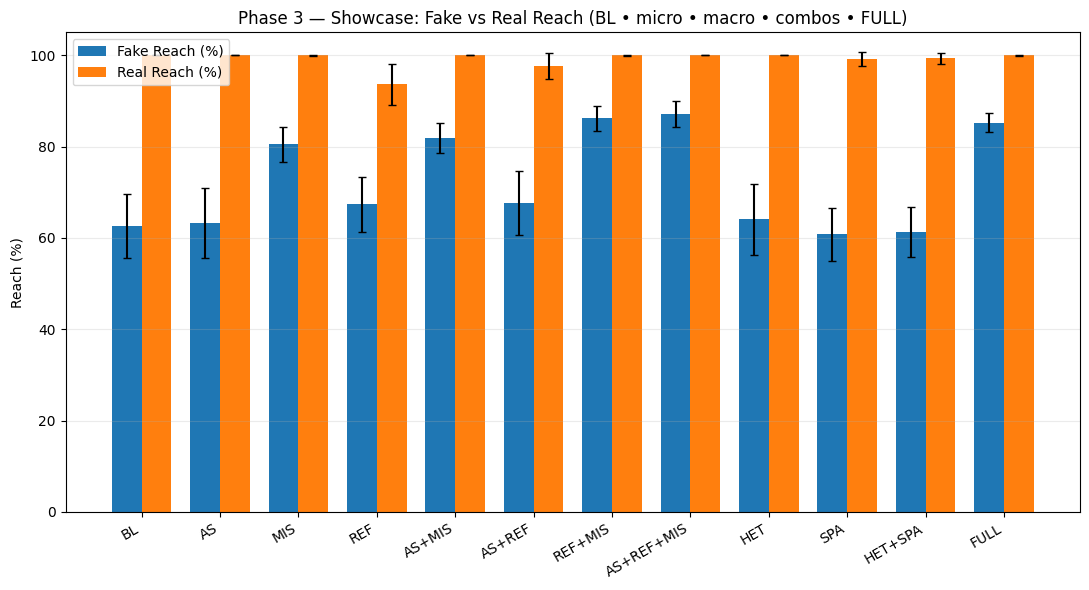

✅ Saved → phase3_plot2_time_to_peak.png


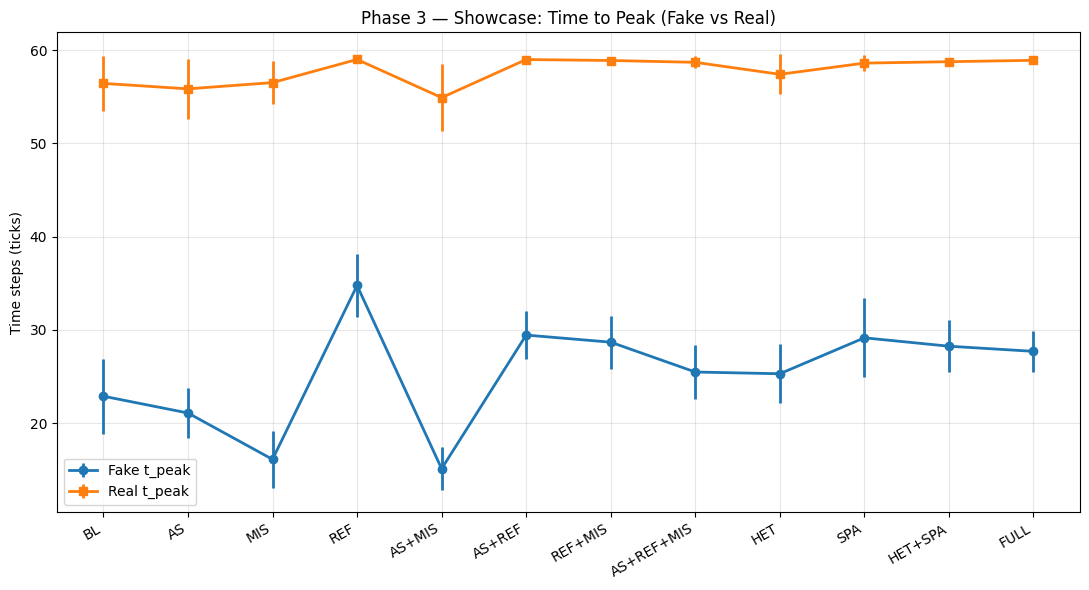

✅ Saved → phase3_plot3_peak_posters.png


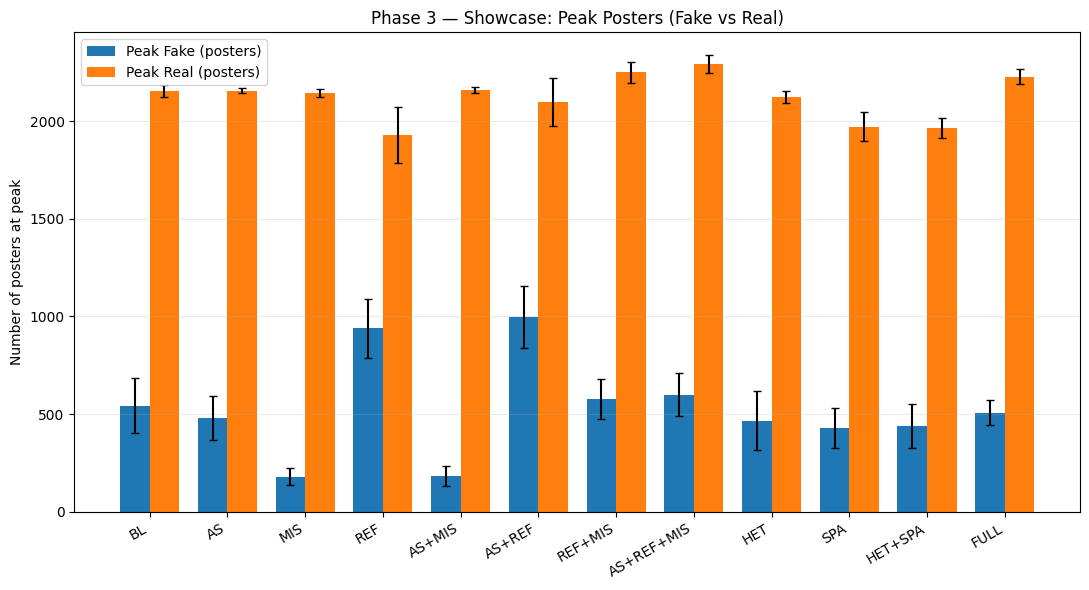

✅ Saved → phase3_plot4_peak_vs_reach_fake.png


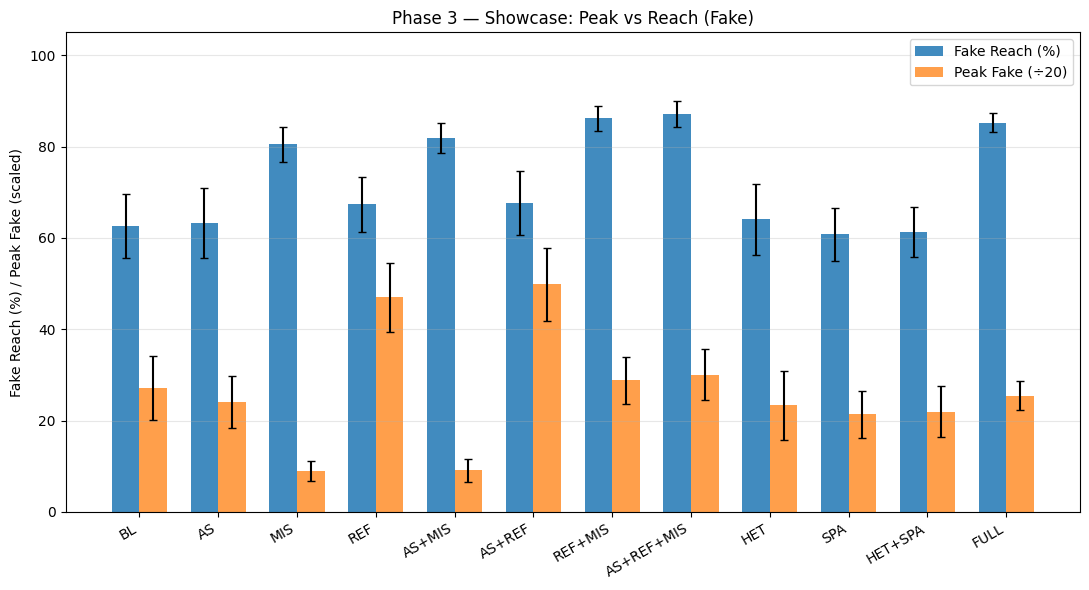

In [28]:
# --- cell 6: Phase 3 — Showcase EVERYTHING side-by-side (BL, micro, macro, micro+macro, FULL) ---
from pathlib import Path
import pandas as pd
import numpy as np
import re

# Output folder for Phase 3 figures
FIGDIR3 = PROJECT_ROOT / "data" / "figures" / "phase3"
FIGDIR3.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------------
# Canonical tokens and helpers (compatible with your run naming)
# --------------------------------------------------------------------
_MICRO_CANON = {
    "as": "as", "async": "as",
    "ref": "ref", "refractory": "ref",
    "mis": "mis", "misclass": "mis",
}
_MACRO_CANON = {
    "het": "het",
    "spa": "spa",
    "het_spa": "het_spa",  # may appear as a combined token in folder name
}
_MICRO_ORDER = ["as", "ref", "mis"]
_MACRO_ORDER = ["het", "spa"]

def _strip_timestamp(name: str) -> str:
    """Remove trailing _YYYYMMDD-HHMMSS from a folder name."""
    return re.sub(r"_\d{8}-\d{6}$", "", name)

def _normalize_tokens_from_name(name: str) -> dict:
    """
    Parse a folder (no timestamp) into canonical tokens.
    Returns:
      {'baseline': bool, 'full': bool, 'micro': set(...), 'macro': set(...)}
    """
    key = name.lower()
    out = {"baseline": False, "full": False, "micro": set(), "macro": set()}

    # Baseline-ish
    if key.startswith(("bl", "baseline", "sync")):
        out["baseline"] = True
        return out

    # FULL
    if key.startswith("full"):
        out["full"] = True
        return out

    parts = [p for p in key.split("_") if p]

    # If 'het_spa' is present, treat as both macros
    if "het_spa" in parts:
        out["macro"].update({"het", "spa"})

    # Map micro tokens (short & legacy)
    for p in parts:
        if p in _MICRO_CANON:
            out["micro"].add(_MICRO_CANON[p])

    # Map macro tokens (short & legacy), except the combined token handled above
    for p in parts:
        if p in _MACRO_CANON and p != "het_spa":
            out["macro"].add(_MACRO_CANON[p])

    return out

def _key_from_tokens(tokens: dict) -> tuple[str, str]:
    """
    Build a canonical key *and* a category:
      categories: 'baseline', 'micro', 'macro', 'micro_macro', 'full', or '' (skip)
    Canonical key examples:
      baseline -> 'bl'
      micro-only as+ref -> 'as_ref'
      macro-only het+spa -> 'het_spa'
      micro+macro as+mis+het -> 'as_mis_het'
      full -> 'full'
    """
    if tokens["baseline"]:
        return "bl", "baseline"
    if tokens["full"]:
        return "full", "full"

    micro_sorted = [t for t in _MICRO_ORDER if t in tokens["micro"]]
    macro_sorted = [t for t in _MACRO_ORDER if t in tokens["macro"]]

    if micro_sorted and macro_sorted:
        return "_".join(micro_sorted + macro_sorted), "micro_macro"
    if micro_sorted:
        return "_".join(micro_sorted), "micro"
    if macro_sorted:
        return "_".join(macro_sorted), "macro"

    # Nothing recognizable
    return "", ""

def _order_tuple(cond_label: str, category: str) -> tuple:
    """
    Produce a sort key so the final chart is readable:
      1) Baseline
      2) Micro (by size then name)
      3) Macro (by size then name)
      4) Micro+Macro combos (by size then name)
      5) FULL (last)
    """
    if category == "baseline":
        return (0, 0, cond_label)
    if category == "micro":
        return (1, cond_label.count("+"), cond_label)
    if category == "macro":
        return (2, cond_label.count("+"), cond_label)
    if category == "micro_macro":
        return (3, cond_label.count("+"), cond_label)
    if category == "full":
        return (4, 999, "ZZZ")
    # default
    return (5, 999, cond_label)

# --------------------------------------------------------------------
# Scan all subfolders and group by canonical key
# --------------------------------------------------------------------
groups = {}   # key -> list of dirs
cat_for = {}  # key -> category
for p in ROOT.iterdir():
    if not p.is_dir():
        continue
    base = _strip_timestamp(p.name)
    toks = _normalize_tokens_from_name(base)
    key, cat = _key_from_tokens(toks)
    if not key:
        continue
    groups.setdefault(key, []).append(p)
    cat_for[key] = cat

if not groups:
    raise RuntimeError(
        "No recognizable Phase 3 folders. "
        "Expected names like 'bl_YYYYMMDD-HHMMSS', 'as_...', 'het_...', "
        "'as_ref_mis_het_spa_...', or 'full_...'."
    )

# --------------------------------------------------------------------
# Summarise each group and attach labels/categories
# --------------------------------------------------------------------
rows = []
missing = []
for key, dirs in sorted(groups.items()):
    stats = summarise_condition(dirs)
    if stats.empty:
        missing.append(key)
        continue
    row = stats.to_dict()
    row["cond"] = key
    row["Category"] = cat_for.get(key, "")
    row["Condition"] = label_for(key)  # short human label e.g. "AS+MIS+HET", "HET+SPA", "FULL", "BL"
    rows.append(row)

phase3_df = pd.DataFrame(rows)
if phase3_df.empty:
    raise RuntimeError("Phase 3: groups were found but all summaries are empty.")

if missing:
    miss_labels = ", ".join(label_for(m) for m in missing)
    print("⚠️  Some groups had no valid summary (skipped):", miss_labels)

# Order for display & plotting
phase3_df["__ord"] = phase3_df.apply(lambda r: _order_tuple(r["Condition"], r["Category"]), axis=1)
phase3_df = (
    phase3_df
    .sort_values("__ord")
    .drop(columns="__ord")
    .reset_index(drop=True)
)

print("✅ Phase 3 — Showcase (BL, micro, macro, combos, FULL):")
display(phase3_df.round(3))

# --------------------------------------------------------------------
# Save Excel for record
# --------------------------------------------------------------------
excel3 = FIGDIR3 / "phase3_metrics.xlsx"
with pd.ExcelWriter(excel3, engine="xlsxwriter") as xw:
    phase3_df.set_index("Condition").round(3).to_excel(xw, sheet_name="Phase3_Showcase")
print(f"Saved Excel → {excel3}")

# --------------------------------------------------------------------
# Figures (re-use your plotting helpers; x-axis uses short labels)
# --------------------------------------------------------------------

# (1) Fake vs Real Reach (grouped bars)
need_reach = {"mean_reachF","std_reachF","mean_reachR","std_reachR"}
if need_reach.issubset(phase3_df.columns):
    plot_grouped_reach(
        phase3_df,
        label_col="Condition",
        figpath=FIGDIR3 / "phase3_plot1_reach_grouped.png",
        title="Phase 3 — Showcase: Fake vs Real Reach (BL • micro • macro • combos • FULL)"
    )
else:
    print("Skipped Plot 1 (Reach): missing columns.")

# (2) Time to Peak (error-line)
need_tpeak = {"mean_t_peak_f","std_t_peak_f","mean_t_peak_r","std_t_peak_r"}
if need_tpeak.issubset(phase3_df.columns):
    plot_time_to_peak(
        phase3_df,
        label_col="Condition",
        figpath=FIGDIR3 / "phase3_plot2_time_to_peak.png",
        title="Phase 3 — Showcase: Time to Peak (Fake vs Real)"
    )
else:
    print("Skipped Plot 2 (Time-to-peak): missing columns.")

# (3) Peak Posters (grouped bars)
need_peaks = {"mean_peak_f","std_peak_f","mean_peak_r","std_peak_r"}
if need_peaks.issubset(phase3_df.columns):
    plot_peak_bars(
        phase3_df,
        label_col="Condition",
        figpath=FIGDIR3 / "phase3_plot3_peak_posters.png",
        title="Phase 3 — Showcase: Peak Posters (Fake vs Real)"
    )
else:
    print("Skipped Plot 3 (Peaks): missing columns.")

# (4) Peak vs Reach (Fake) — Grouped Bars (scaled)
need_combo = {"mean_peak_f","std_peak_f","mean_reachF","std_reachF"}
if need_combo.issubset(phase3_df.columns):
    plot_peak_vs_reach_bar(
        phase3_df,
        label_col="Condition",
        figpath=FIGDIR3 / "phase3_plot4_peak_vs_reach_fake.png",
        title="Phase 3 — Showcase: Peak vs Reach (Fake)",
        scale=20
    )
else:
    print("Skipped Plot 4 (Peak vs Reach): need peak_f and reachF columns.")
